In [1]:
import os, sys, joblib, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
from pathlib import Path
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              recall_score, confusion_matrix)

try:
    _nb = globals().get('__vsc_ipynb_file__')
    if _nb:
        os.chdir(os.path.dirname(os.path.dirname(_nb)))
except Exception:
    pass

%load_ext autoreload
%autoreload 2
import config
%matplotlib inline

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.color': '#e0e0e0',
    'grid.linestyle': '--',
    'grid.alpha': 0.7,
    'font.size': 10,
})
print("CWD:", os.getcwd())



[*] SUCCESS: TensorFlow is utilizing the GPU -> /physical_device:GPU:0

CWD: /vol/bitbucket/gk225/POC_DDM/gk_code/main


In [2]:
sys.path.insert(0, 'utils')
sys.path.insert(0, 'utils/model_training')
from model_utils import build_well_stratified_random_split, build_well_stratified_nfold_splits
from sklearn.preprocessing import LabelEncoder

def reconstruct_well_splits(y_full, well_ids_full, mask=None, n_splits=1, random_state=0):
    """Replays evaluate_outlier_filters' own mask -> rare-class-drop -> well-stratified-split
    procedure (utils/model_training/model_utils.py:863-916) exactly, so the returned test-set
    well_ids line up with the cached y_trues_/y_preds_AC_* arrays. mask=None means the
    outlier_filter=None case (no rows removed pre-split). n_splits=1 uses the same
    max(10%, n_wells) test_size floor evaluate_outlier_filters uses for its single-split
    case; n_splits>1 returns that many well-stratified CV folds.
    Returns a list of (y_values_fold, well_ids_fold) pairs, one per fold, in the same
    order as evaluate_outlier_filters' own `splits` list."""
    if mask is None:
        mask = np.ones(len(y_full), dtype=bool)
    y_m, w_m = y_full[mask], well_ids_full[mask]

    unique_classes, class_counts = np.unique(y_m, return_counts=True)
    rare = unique_classes[class_counts < 2]
    valid = ~np.isin(y_m, rare)
    y_v, w_v = y_m[valid], w_m[valid]

    if n_splits == 1:
        n_wells = len(np.unique(w_v))
        test_size = max(len(y_v) * 0.10, n_wells) / len(y_v)
        splits = list(build_well_stratified_random_split(
            y_v, w_v, test_size=test_size, random_state=random_state).values())
    else:
        actual_splits = min(n_splits, len(np.unique(w_v)))
        splits = list(build_well_stratified_nfold_splits(
            y_v, w_v, n_splits=actual_splits, random_state=random_state).values())

    return [(y_v[test_idx], w_v[test_idx]) for _, test_idx in splits]

def remap_well_splits(well_ids_full, y_full, mask, global_splits):
    """Mirrors _remap_global_splits (utils/model_training/model_utils.py:710) plus the
    rare-class-drop step inside evaluate_outlier_filters, for the cv_splits-supplied path
    used by 04_cross_dataset_training.py's kfold/lofo modes -- where the split is computed
    ONCE on the full (unmasked) pool and then masked/remapped per outlier filter, rather
    than split fresh per filter like reconstruct_well_splits above.
    global_splits: dict or list of (train_idx, test_idx) pairs in full-pool index space.
    Returns a dict/list (matching global_splits' own container type) of
    (y_values_fold, well_ids_fold) pairs."""
    kept_global = np.where(mask)[0]
    y_m, w_m = y_full[mask], well_ids_full[mask]
    unique_classes, class_counts = np.unique(y_m, return_counts=True)
    rare = unique_classes[class_counts < 2]
    valid = ~np.isin(y_m, rare)
    kept_global = kept_global[valid]
    y_v, w_v = y_m[valid], w_m[valid]
    pos_lookup = {g: i for i, g in enumerate(kept_global)}

    def _remap_one(test_idx):
        local_test = np.array([pos_lookup[g] for g in test_idx if g in pos_lookup], dtype=int)
        return y_v[local_test], w_v[local_test]

    if isinstance(global_splits, dict):
        return {k: _remap_one(test_idx) for k, (_, test_idx) in global_splits.items()}
    return [_remap_one(test_idx) for _, test_idx in global_splits]

def well_level_accuracy(y_trues_flat, preds_flat, well_ids_test):
    """Majority-votes each well's pixel predictions into one verdict; accuracy over wells.
    The true label per well should be unanimous (one well = one label) -- a mismatch
    there signals a split-reconstruction bug, not real label noise."""
    wells = np.unique(well_ids_test)
    n_true_mismatch = 0
    correct = 0
    for w in wells:
        m = well_ids_test == w
        true_vals = pd.Series(y_trues_flat[m])
        if true_vals.nunique() > 1:
            n_true_mismatch += 1
        true_label = true_vals.mode()[0]
        pred_label = pd.Series(preds_flat[m]).mode()[0]
        correct += int(true_label == pred_label)
    if n_true_mismatch:
        print(f"  [!] {n_true_mismatch} well(s) had a non-unanimous true label -- "
              f"split reconstruction likely mismatched training.")
    return correct / len(wells), len(wells)

def verified_well_ids(y_true_cached, folds, context=""):
    """folds: list of (y_values_fold, well_ids_fold) pairs (from reconstruct_well_splits /
    remap_well_splits), covering the same rows as y_true_cached once concatenated in fold
    order. Returns the concatenated well_ids only if the concatenated y-values match
    y_true_cached exactly (length AND values) -- otherwise warns and returns None, so a
    reconstruction bug never silently produces a wrong well_accuracy number."""
    if not folds:
        return None
    y_check = np.concatenate([y for y, _ in folds])
    well_ids = np.concatenate([w for _, w in folds])
    if len(y_check) != len(y_true_cached) or not np.array_equal(y_check, y_true_cached):
        print(f"  [!] well-id reconstruction mismatch ({context}) -- skipping well_accuracy.")
        return None
    return well_ids

def verified_well_folds(cached_y_folds, folds, context=""):
    """Per-fold version of verified_well_ids -- for compute_fold_accuracy_stats, which needs
    one well_ids array per fold (not pooled) to compute a mean/std across folds. Returns a
    list of well_ids arrays (same fold order as cached_y_folds) only if every fold's
    y-values match exactly; otherwise warns and returns None."""
    if folds is None or len(folds) != len(cached_y_folds):
        print(f"  [!] well-id reconstruction mismatch ({context}: fold count) -- skipping well_accuracy.")
        return None
    out = []
    for (y_v, w_v), yt in zip(folds, cached_y_folds):
        if len(y_v) != len(yt) or not np.array_equal(y_v, yt):
            print(f"  [!] well-id reconstruction mismatch ({context}) -- skipping well_accuracy.")
            return None
        out.append(w_v)
    return out


In [3]:
FAMILIES = [
            'cnn_gru_dual', 
            'cnn_gru_dual_attn_recon', 
            ]
# SC_LEVELS = [0, 1, 2, 3]
SC_LEVELS = [0]

MODEL_KEY = {
    (fam, 0): fam for fam in FAMILIES
}

MODELS = [MODEL_KEY[(fam, sc)] for sc in SC_LEVELS for fam in FAMILIES]
MODEL_TO_FAMILY = {MODEL_KEY[(fam, sc)]: fam for sc in SC_LEVELS for fam in FAMILIES}

# ── Paths ─────────────────────────────────────────────────────────────────────

EXP_FOLDER = config.FINAL_EXP_FOLDER

TARGET_FOLDERS = config.CROSS_DATASET_GROUPS['final_6_new']

def short_name(folder):
    m = re.search(r'DDM_0(\d)', folder)
    return f'Chip 0{m.group(1)}' if m else folder.split('_U_', 1)[1]

DATASET_NAMES = [short_name(f) for f in TARGET_FOLDERS]

# ── Labels ────────────────────────────────────────────────────────────────────
# Standard model naming, shared across every section of this notebook (RQ2, RQ3.1, RQ3.2)
# and mirrored verbatim in 0_LOFO_INSPECTION.ipynb -- the single source of truth for how a
# model key is displayed on any chart.
FAMILY_LABELS = {
    'cnn_gru_dual': 'CNN-BiGRU',
    'cnn_gru_dual_dann': 'CNN-BiGRU\n+ DANN',
    'cnn_gru_dual_supcon3': 'CNN-BiGRU\n+ Contrastive Loss (SC3)',
    'cnn_gru_dual_pc_recenter': 'CNN-BiGRU\n+ Latent Alignment',

    'cnn_gru_dual_attn_recon':   'CNN-BiGRU + Spatial Attn',
    'cnn_gru_dual_attn_recon_aug': 'CNN-BiGRU + Spatial Attn\n+ Temporal Aug',
    'cnn_gru_dual_attn_recon_dann': 'CNN-BiGRU + Spatial Attn\n+ DANN',
    'cnn_gru_dual_attn_recon_supcon3': 'CNN-BiGRU + Spatial Attn\n+ Contrastive Loss (SC3)',
    'cnn_gru_dual_attn_recon_pc_recenter': 'CNN-BiGRU + Spatial Attn\n+ Latent Alignment',

    'cnn_gru_dual_cosine_recon': 'CNN-BiGRU + Cosine Recon',
    'ccgd_arch_poc_st': 'CCGD-ST',

    'knn': 'kNN',
    'cnn_gru_dual_attn_recon_dann_pc_recenter': 'CNN-BiGRU + Spatial Attn\n+ DANN + Latent Alignment',
    'cnn_gru_dual_attn_recon_supcon3_pc_recenter': 'CNN-BiGRU + Spatial Attn\n+ Contrastive Loss (SC3) + Latent Alignment',
    'cnn_gru_dual_attn_recon_aug_pc_recenter': 'CNN-BiGRU + Spatial Attn\n+ Temporal Aug + Latent Alignment',
    'cnn_gru_dual_attn_recon_mtl': 'CNN-BiGRU + Spatial Attn\n+ MTL',
    'cnn_gru_dual_attn_recon_mtl_pc_recenter': 'CNN-BiGRU + Spatial Attn\n+ MTL + Latent Alignment',
    'cnn_gru_dual_attn_recon_coral': 'CNN-BiGRU + Spatial Attn\n+ CORAL',
    'cnn_gru_dual_attn_recon_coral_pc_recenter': 'CNN-BiGRU + Spatial Attn\n+ CORAL + Latent Alignment',
    'cnn_gru_dual_attn_recon_dann_conc': 'CNN-BiGRU + Spatial Attn\n+ DANN (Conc)',
    'cnn_gru_dual_attn_recon_dann_conc_pc_recenter': 'CNN-BiGRU + Spatial Attn\n+ DANN (Conc) + Latent Alignment',
}

# ── Colors ────────────────────────────────────────────────────────────────────
# dataviz-skill validated categorical palette, assigned in a `models`-list's order --
# shared by every grouped-bar-by-model chart in this notebook (RQ2 and RQ3.1 alike).
PALETTE = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100',
           '#e87ba4', '#008300', '#4a3aa7', '#e34948']

print(f"{len(MODELS)} models defined.")
print("  " + "\n  ".join(MODELS))


2 models defined.
  cnn_gru_dual
  cnn_gru_dual_attn_recon


In [4]:
TARGET_FOLDERS

['D20260827_E00_C00_F4500KHz_U_DDM_01_final_final',
 'D20260827_E00_C00_F4500KHz_U_DDM_02_final_final',
 'D20260827_E00_C00_F4500KHz_U_DDM_03_final_final',
 'D20260827_E00_C00_F4500KHz_U_DDM_04_final_final',
 'D20260825_E00_C00_F4500KHz_U_DDM_05_01',
 'D20260825_E00_C00_F4500KHz_U_DDM_06_02']

In [5]:
def compute_metrics(perf, model_key, well_ids=None):
    """Return dict with accuracy/f1/auc/sensitivity/specificity, or None if missing.
    well_ids (optional): array aligned 1:1 with concatenate(perf['y_trues_']) -- adds
    well_accuracy/n_wells (majority-vote-per-well accuracy) alongside the pixel-level
    metrics above. Pass an already length/value-verified array (see verified_well_ids)."""
    pred_k = f'y_preds_AC_{model_key}_'
    prob_k = f'y_probs_AC_{model_key}_'
    if pred_k not in perf:
        return None

    y_true  = np.concatenate(perf['y_trues_'])
    y_pred  = np.concatenate(perf[pred_k])
    y_probs = np.concatenate(perf[prob_k]) if prob_k in perf else None
    n_cls   = len(np.unique(y_true))

    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)
    sens = recall_score(y_true, y_pred, average='macro', zero_division=0)

    if y_probs is not None and n_cls > 1:
        try:
            auc = roc_auc_score(y_true, y_probs, multi_class='ovr', average='macro')
        except Exception:
            auc = np.nan
    else:
        auc = np.nan

    # Specificity = TN/(TN+FP) per class, macro-averaged
    cm = confusion_matrix(y_true, y_pred)
    specs = []
    for i in range(n_cls):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - cm[i, :].sum() - fp
        specs.append(tn / (tn + fp) if (tn + fp) > 0 else 0.0)

    out = {'accuracy': acc, 'f1': f1, 'auc': auc,
           'sensitivity': sens, 'specificity': float(np.mean(specs))}

    if well_ids is not None:
        well_acc, n_wells = well_level_accuracy(y_true, y_pred, well_ids)
        out['well_accuracy'] = well_acc
        out['n_wells'] = n_wells

    return out


In [6]:
def macro_f1_sens_spec(y_true, y_pred):
    """F1/sensitivity (recall) macro-averaged, plus specificity (TN/(TN+FP) per class,
    macro-averaged) -- the exact computation compute_metrics uses on a single pooled
    split, factored out so compute_fold_accuracy_stats/load_cv_accuracy can call it once
    per fold instead (giving a real mean/std across folds rather than one pooled value)."""
    n_cls = len(np.unique(y_true))
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)
    sens = recall_score(y_true, y_pred, average='macro', zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    specs = []
    for i in range(n_cls):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - cm[i, :].sum() - fp
        specs.append(tn / (tn + fp) if (tn + fp) > 0 else 0.0)
    return f1, sens, float(np.mean(specs))


# RQ3.2: LOFO

In [7]:
import importlib

b06 = importlib.import_module("06b_cross_dataset_prediction_report")

def cv_group_dir(group_name):
    return Path(EXP_FOLDER) / "cross_dataset_cv" / group_name


In [8]:
def plot_grouped_bar_by_model(df, x_col, x_order, models, model_labels,
                               value_col='accuracy', value_label=None, xlabel='', title='', figsize=(10, 6), plot_fold=True, plot_summary=True, show_std=True):

    n_models = len(models)
    ylabel = value_label or f'{value_col.replace("_", " ").title()} (%)'

    if plot_fold:
        bar_w = 0.8 / n_models
        x = np.arange(len(x_order))

        fig, ax = plt.subplots(figsize=figsize)
        for mi, model in enumerate(models):
            sub = df[df.model == model].set_index(x_col)[value_col]
            ys = np.array([sub.get(v, np.nan) for v in x_order])
            offset = (mi - (n_models - 1) / 2) * bar_w
            ax.bar(x + offset, np.nan_to_num(ys, nan=0), width=bar_w,
                color=PALETTE[mi % len(PALETTE)],
                label=model_labels.get(model, model),
                edgecolor='white', linewidth=0.8)
            for xi, yi in zip(x + offset, ys):
                if not np.isnan(yi):
                    ax.text(xi, yi + 0.5, f'{yi:.2f}', ha='center', va='bottom', fontsize=8)

        ax.set_xticks(x)
        ax.set_xticklabels(x_order)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_ylim(0, 108)
        ax.legend(title='Model', fontsize=8, loc='lower right', framealpha=0.9, bbox_to_anchor=(1.5,0))
        ax.set_title(title, fontsize=11, fontweight='bold')
        fig.tight_layout()
        plt.show()

    stats = df.groupby('model')[value_col].agg(['mean', 'std']).reindex(models)

    if plot_summary:
        mean_v = stats['mean'].to_numpy()
        std_v  = np.nan_to_num(stats['std'].to_numpy(), nan=0)
        x2 = np.arange(n_models)

        fig2, ax2 = plt.subplots(figsize=(0.75 * n_models + 2, 6))
        if show_std:
            ax2.bar(x2, np.nan_to_num(mean_v, nan=0), yerr=std_v, capsize=4,
                color=[PALETTE[mi % len(PALETTE)] for mi in range(n_models)],
                edgecolor='white', linewidth=0.8,
                error_kw=dict(ecolor='#3a3a3a', elinewidth=1.2))
        else:
            ax2.bar(x2, np.nan_to_num(mean_v, nan=0),
                color=[PALETTE[mi % len(PALETTE)] for mi in range(n_models)],
                edgecolor='white', linewidth=0.8)
        for xi, mv, sv in zip(x2, mean_v, std_v):
            if np.isnan(mv):
                continue
            # ax2.text(xi, mv + sv + 0.5, f'{mv:.2f} \u00b1 {sv:.2f}', ha='center', va='bottom', fontsize=12)
            if show_std:
                ax2.text(xi, mv + sv + 0.5, f'{mv:.2f} \u00b1 {sv:.2f}', ha='center', va='bottom', fontsize=11)
            else:
                ax2.text(xi, mv + 0.5, f'{mv:.2f}', ha='center', va='bottom', fontsize=11)

        ax2.set_xticks(x2)
        ax2.set_xticklabels([model_labels.get(m, m) for m in models], fontsize=9, rotation=30, ha='right')
        ax2.set_ylabel(ylabel)
        ax2.set_ylim(0, 108)
        ax2.set_title(f'{title}\nMean \u00b1 std across {len(x_order)} {xlabel.lower()}s',
                    fontsize=11, fontweight='bold')
        fig2.tight_layout()
        plt.show()
    return stats


In [9]:
p08   = importlib.import_module("08_cross_dataset_predict_new_chip")
vis07 = importlib.import_module("07_attribution_vis_all")
rio   = importlib.import_module("cross_dataset_result_io")

import tensorflow as tf
tf.config.optimizer.set_jit(False)

LOFO_MODE_STR      = "lofo"
LOFO_CURVE_ALIGN   = "pc_ttp"
LOFO_PC_TTP_ANCHOR = "min"
LOFO_FRAC          = 0.5  # matches --train_center_frac on f_lf_g13.sh
LOFO_FILTER        = "noamp_remove"
LOFO_CURVE_TYPES = ["ori_curve_sg_p4_norm"]
LOFO_CURVE_SHORT = {"ori_curve_sg_p4_norm": "sgp4_norm"}
LOFO_GROUP_NAMES = ["final_6_new"]

RQ3_2_BASE_MODELS = ["knn", "cnn_gru_dual", "cnn_gru_dual_attn_recon",
                     "cnn_gru_dual_attn_recon_dann", "cnn_gru_dual_attn_recon_supcon3",
                     "cnn_gru_dual_attn_recon_aug", "cnn_gru_dual_attn_recon_mtl",
                     "cnn_gru_dual_attn_recon_coral", "cnn_gru_dual_attn_recon_dann_conc"]
PC_RECENTER_BASES = ["cnn_gru_dual_attn_recon", "cnn_gru_dual_attn_recon_dann",
                     "cnn_gru_dual_attn_recon_supcon3", "cnn_gru_dual_attn_recon_aug",
                     "cnn_gru_dual_attn_recon_mtl", "cnn_gru_dual_attn_recon_coral",
                     "cnn_gru_dual_attn_recon_dann_conc"]
RQ3_2_COMPARISON = RQ3_2_BASE_MODELS + [f"{m}_pc_recenter" for m in PC_RECENTER_BASES]

def lofo_group_dir(group_name):
    return b06.alignment_dir(cv_group_dir(group_name), LOFO_CURVE_ALIGN, LOFO_PC_TTP_ANCHOR)

def load_lofo_results(group_name, curve_type, train_center_frac=LOFO_FRAC):
    out_dir = lofo_group_dir(group_name)
    legacy_path = b06.find_results_path(out_dir, LOFO_MODE_STR, curve_type)
    return b06.load_partitioned(out_dir, LOFO_MODE_STR, curve_type, legacy_path=legacy_path,
                                train_center_frac=train_center_frac)

In [10]:
LOFO_CURVE_TYPES

['ori_curve_sg_p4_norm']

In [11]:
PC_RECENTER_CACHE_NAME = "pc_recenter_sweep_cache.joblib"

def _pc_cache_path(group_name):
    return Path(EXP_FOLDER) / "cross_dataset_cv" / group_name / PC_RECENTER_CACHE_NAME

def load_pc_cache(group_name):
    path = _pc_cache_path(group_name)
    if not path.exists():
        return {}
    try:
        return joblib.load(path)
    except Exception:
        return {}

def save_pc_cache(group_name, cache):
    path = _pc_cache_path(group_name)
    path.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(cache, path, compress=3)

def _mtime(path):
    try:
        return path.stat().st_mtime
    except FileNotFoundError:
        return None

def pc_cache_signature(model_path, out_dir, curve_type, held_out_chip=None):
    align_dir = config.cross_dataset_alignment_dir(out_dir, held_out_chip)
    return (_mtime(model_path),
           _mtime(align_dir / config.CROSS_DATASET_RESAMPLER_PATH.format(curve_type=curve_type)),
           _mtime(align_dir / config.CROSS_DATASET_PC_TTP_RECIPE_PATH.format(curve_type=curve_type)))


In [12]:
def lofo_ground_truth(chip_name, Y_well_raw, class_names):
    mapping = config.LABEL_MAPPINGS[chip_name]
    y_true = np.array([mapping.get(w, w) for w in Y_well_raw])
    if class_names:
        cn = list(class_names)
        y_true = np.array([next((c for c in cn if y == c or y.startswith(c + '-') or c.startswith(y + '-')), y)
                           for y in y_true])
    return y_true


def lofo_pc_recenter_accuracy(group_name, curve_type, base_model, chip_path, exp_paths_all, class_names, cache,
                              train_center_frac=LOFO_FRAC):
    out_dir = lofo_group_dir(group_name)
    chip_name = chip_path.name
    fold_label = f"lofo_{chip_name}"
    model_dir = out_dir / "model_interpretation" / fold_label
    model_path = model_dir / f"{base_model}_{LOFO_FILTER}_{curve_type}{rio.frac_suffix(train_center_frac)}_model.keras"
    if not model_path.exists():
        return None

    cache_key = (curve_type, LOFO_CURVE_ALIGN, LOFO_PC_TTP_ANCHOR, train_center_frac, LOFO_FILTER, base_model, chip_name)
    sig = pc_cache_signature(model_path, out_dir, curve_type, held_out_chip=chip_name)
    cached = cache.get(cache_key)
    # "cm_base" not in cached["row"] catches pre-existing cache entries saved before
    # confusion matrices were added to this row -- self-heals with one recompute.
    if cached is not None and cached["sig"] == sig and "cm_base" in cached["row"]:
        return cached["row"]

    align_result = p08.align_new_chip(chip_path, out_dir, curve_type, LOFO_CURVE_ALIGN, LOFO_PC_TTP_ANCHOR,
                                      group_name=group_name, held_out_chip=chip_name)
    if align_result is None:
        return None
    curves, resampler, Y_well_raw, pc_curves_aligned, coords, well_ids = align_result

    loaded = vis07.load_saved_models(model_dir, LOFO_FILTER, len(resampler.t_grid), curve_type=curve_type,
                                     model_names=[base_model], train_center_frac=train_center_frac)
    if base_model not in loaded:
        return None
    model = loaded[base_model]
    if p08._is_spatial(base_model) and (coords is None or well_ids is None):
        return None

    y_true = lofo_ground_truth(chip_name, Y_well_raw, class_names)
    valid = y_true != "PC"
    exp_paths_train = [p for p in exp_paths_all if p.name != chip_name]

    probs_base, _ = p08.predict_new_chip(model, base_model, curves, coords, well_ids, pc_curves_aligned,
                                         exp_paths_train, out_dir, curve_type, LOFO_FILTER, LOFO_CURVE_ALIGN,
                                         pc_recenter=False, held_out_chip=chip_name)
    pred_base = np.array(class_names)[np.argmax(probs_base, axis=1)]
    acc_base = (pred_base[valid] == y_true[valid]).mean() if valid.any() else float('nan')
    cm_base = confusion_matrix(y_true[valid], pred_base[valid], labels=class_names) if valid.any() else None

    acc_recenter = float('nan')
    cm_recenter = None
    try:
        probs_r, _ = p08.predict_new_chip(model, base_model, curves, coords, well_ids, pc_curves_aligned,
                                          exp_paths_train, out_dir, curve_type, LOFO_FILTER, LOFO_CURVE_ALIGN,
                                          pc_recenter=True, force_rerun=True, held_out_chip=chip_name)
        pred_r = np.array(class_names)[np.argmax(probs_r, axis=1)]
        acc_recenter = (pred_r[valid] == y_true[valid]).mean() if valid.any() else float('nan')
        cm_recenter = confusion_matrix(y_true[valid], pred_r[valid], labels=class_names) if valid.any() else None
    except ValueError:
        pass   # no PC snapshot for this chip -- leave acc_recenter/cm_recenter as NaN/None

    row = {"acc_baseline": acc_base * 100, "acc_pc_recenter": acc_recenter * 100, "n_pixels": int(valid.sum()),
          "cm_base": cm_base, "cm_recenter": cm_recenter, "class_names": list(class_names)}
    cache[cache_key] = {"sig": sig, "row": row}
    save_pc_cache(group_name, cache)

    del model, loaded
    tf.keras.backend.clear_session()
    return row


In [13]:
def _lofo_well_ids_for_chip(group_name, curve_type, chip_path, class_names):
    """noamp_remove-filtered, label-verified well_ids for one held-out chip's LOFO test set.
    Reuses align_new_chip() (same call lofo_pc_recenter_accuracy below makes) since it reads
    the SAME saved resampler/pc_ttp recipe 04_cross_dataset_training.py saved for this exact
    held-out chip -- its curve output is the held-out chip's own rows of the LOFO training
    pool, in the pool's original row order. noamp_remove is applied by hand (predict_new_chip
    doesn't do this itself -- see 08_cross_dataset_predict_new_chip.py's __main__ block) to
    match what evaluate_outlier_filters actually filtered res_entry down to. Labels not found
    in class_names (e.g. PC) are dropped, same as lofo_pc_recenter_accuracy's own `valid` mask
    below; verified_well_ids catches any remaining mismatch (e.g. the rare-class-drop
    evaluate_outlier_filters also applies) and skips well_accuracy rather than risk a wrong
    number."""
    out_dir = lofo_group_dir(group_name)
    chip_name = chip_path.name
    align_result = p08.align_new_chip(chip_path, out_dir, curve_type, LOFO_CURVE_ALIGN, LOFO_PC_TTP_ANCHOR,
                                      group_name=group_name, held_out_chip=chip_name)
    if align_result is None:
        return None
    curves, resampler, Y_well_raw, pc_curves_aligned, coords, well_ids = align_result
    if well_ids is None:
        print(f"  [!] {group_name}/{curve_type}/{chip_name}: no pixel_row_idx/pixel_col_idx metadata (well_ids unavailable) -- well_accuracy skipped.")
        return None

    keep = p08.cdt.is_amplifying_mask(curves)
    Y_well_raw, well_ids = Y_well_raw[keep], well_ids[keep]

    y_true_str = lofo_ground_truth(chip_name, Y_well_raw, class_names)
    label_to_idx = {c: i for i, c in enumerate(class_names)}
    valid = np.array([lbl in label_to_idx for lbl in y_true_str])
    y_true_int = np.array([label_to_idx.get(lbl, -1) for lbl in y_true_str])
    return y_true_int[valid], well_ids[valid]


def macro_f1_sens_spec_from_cm(cm):
    n_cls = cm.shape[0]
    f1s, senss, specs = [], [], []
    for i in range(n_cls):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - tp - fn - fp
        sens = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        prec = tp / (tp + fp) if (tp + fp) > 0 else np.nan
        spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan
        f1 = (2 * prec * sens / (prec + sens)
             if not np.isnan(prec) and not np.isnan(sens) and (prec + sens) > 0 else np.nan)
        f1s.append(f1); senss.append(sens); specs.append(spec)
    return np.nanmean(f1s), np.nanmean(senss), np.nanmean(specs)


def load_lofo_accuracy(groups=None, group_indices=None, train_center_frac=LOFO_FRAC):
    if groups is None:
        if group_indices is not None:
            groups = [list(config.CROSS_DATASET_GROUPS)[i] for i in group_indices]
        else:
            groups = list(config.CROSS_DATASET_GROUPS)
    all_models = RQ3_2_BASE_MODELS
    rows = []
    for group_name in groups:
        exp_paths_all = [Path(EXP_FOLDER, name) for name in config.CROSS_DATASET_GROUPS[group_name]]
        pc_cache = None

        for curve_type in LOFO_CURVE_TYPES:
            lofo_results = load_lofo_results(group_name, curve_type, train_center_frac=train_center_frac)
            if not any(k != "full_data" for k in lofo_results):
                continue
            if pc_cache is None:
                pc_cache = load_pc_cache(group_name)

            for chip_path in exp_paths_all:
                fold_entry = lofo_results.get(f"lofo_{chip_path.name}", {})
                res_entry = fold_entry.get(LOFO_FILTER)
                class_names = fold_entry.get("class_names")
                fold = short_name(chip_path.name)

                if res_entry is not None:
                    y_true_full = np.concatenate(res_entry["y_trues_"])
                    # Prefer well_ids_test_ (saved directly by evaluate_outlier_filters -- see
                    # utils/model_training/model_utils.py) over replaying the split -- skips
                    # _lofo_well_ids_for_chip's align_new_chip() call entirely once present.
                    saved_well_ids = res_entry.get('well_ids_test_')
                    if saved_well_ids is not None:
                        well_ids_test = np.concatenate(saved_well_ids)
                    else:
                        well_ids_test = None
                        if class_names is not None:
                            try:
                                well_check = _lofo_well_ids_for_chip(group_name, curve_type, chip_path, class_names)
                            except Exception as e:
                                print(f"  [!] {group_name}/{curve_type}/{fold}: could not reconstruct well_ids ({e}) -- well_accuracy skipped.")
                                well_check = None
                            if well_check is not None:
                                well_ids_test = verified_well_ids(y_true_full, [well_check],
                                                                  context=f'{group_name}/{curve_type}/{fold}')

                    for model in all_models:
                        preds_key = config.MODEL_KEY_MAP.get(model, (None,))[0]
                        if preds_key is None or preds_key not in res_entry:
                            continue
                        y_pred = np.concatenate(res_entry[preds_key])
                        f1, sens, spec = macro_f1_sens_spec(y_true_full, y_pred)
                        row = dict(group=group_name, curve_type=LOFO_CURVE_SHORT.get(curve_type, curve_type),
                                  fold=fold, model=model,
                                  accuracy=accuracy_score(y_true_full, y_pred) * 100,
                                  f1=f1 * 100, sensitivity=sens * 100, specificity=spec * 100,
                                  n_test=len(y_true_full),
                                  well_accuracy=np.nan, n_wells=np.nan)
                        if well_ids_test is not None:
                            well_acc, n_wells = well_level_accuracy(y_true_full, y_pred, well_ids_test)
                            row["well_accuracy"] = well_acc * 100
                            row["n_wells"] = n_wells
                        rows.append(row)

                if class_names is None:
                    continue
                for base_model in PC_RECENTER_BASES:
                    result = lofo_pc_recenter_accuracy(group_name, curve_type, base_model, chip_path,
                                                       exp_paths_all, class_names, pc_cache,
                                                       train_center_frac=train_center_frac)
                    if result is None:
                        continue
                    cm_r = result.get("cm_recenter")
                    if cm_r is not None:
                        f1_r, sens_r, spec_r = macro_f1_sens_spec_from_cm(cm_r)
                    else:
                        f1_r = sens_r = spec_r = np.nan
                    rows.append(dict(group=group_name, curve_type=LOFO_CURVE_SHORT.get(curve_type, curve_type),
                                     fold=fold, model=f"{base_model}_pc_recenter",
                                     accuracy=result["acc_pc_recenter"],
                                     f1=f1_r * 100, sensitivity=sens_r * 100, specificity=spec_r * 100,
                                     n_test=result["n_pixels"]))
    # Explicit columns so an empty result (e.g. train_center_frac results not
    # finished training yet) still has 'group'/'curve_type' etc. to groupby --
    # otherwise a 0-row, 0-column DataFrame KeyErrors every downstream groupby.
    return pd.DataFrame(rows, columns=['group', 'curve_type', 'fold', 'model', 'accuracy', 'f1', 'sensitivity', 'specificity', 'n_test', 'well_accuracy', 'n_wells'])

lofo_df = load_lofo_accuracy(group_indices=[list(config.CROSS_DATASET_GROUPS).index('final_6_new')])
print(f"Loaded {len(lofo_df)} rows  |  "
      f"{lofo_df.group.nunique()} groups  "
      f"{lofo_df.curve_type.nunique()} curve types  "
      f"{lofo_df.fold.nunique()} folds  "
      f"{lofo_df.model.nunique()} models")
lofo_df.head(8)


  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 1774 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260827_E00_C00_F4500KHz_U_DDM_04_final_final


  [PC-TTP align] new chip TTP=290.28  anchor=281.24  shift=9.04


/vol/bitbucket/gk225/venv_poc_ddm/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 82 variables whereas the saved optimizer has 78 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/vol/bitbucket/gk225/venv_poc_ddm/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 78 variables whereas the saved optimizer has 0 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


InternalError: Graph execution error:

Detected at node dann_model_1/time_distributed_1/dense_25/MatMul defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/vol/bitbucket/gk225/venv_poc_ddm/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/vol/bitbucket/gk225/venv_poc_ddm/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/vol/bitbucket/gk225/venv_poc_ddm/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 758, in start

  File "/vol/bitbucket/gk225/venv_poc_ddm/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 211, in start

  File "/usr/lib/python3.12/asyncio/base_events.py", line 641, in run_forever

  File "/usr/lib/python3.12/asyncio/base_events.py", line 1987, in _run_once

  File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run

  File "/vol/bitbucket/gk225/venv_poc_dd

In [14]:
def lofo_completeness(df, comparison_models, label):
    check = (df[df.model.isin(comparison_models)]
               .groupby(['group', 'curve_type', 'fold'])
               .size()
               .reset_index(name='n')
               .assign(expected=len(comparison_models), ok=lambda x: x.n == x.expected))
    missing = check[~check.ok]
    if missing.empty:
        print(f"[{label}] All combinations fully populated.")
    else:
        print(f"[{label}] Incomplete combinations:")
        display(missing)

lofo_completeness(lofo_df, RQ3_2_COMPARISON, "RQ3.2 (16-model comparison)")


[RQ3.2 (16-model comparison)] Incomplete combinations:


,group,curve_type,fold,n,expected,ok
0,final_6_new,sgp4_norm,Chip 01,12,16,False
1,final_6_new,sgp4_norm,Chip 02,12,16,False
2,final_6_new,sgp4_norm,Chip 03,12,16,False
3,final_6_new,sgp4_norm,Chip 04,12,16,False
4,final_6_new,sgp4_norm,Chip 05,12,16,False
5,final_6_new,sgp4_norm,Chip 06,12,16,False


### LOFO confusion matrices -- 1 figure per model, 1 panel per held-out chip

Computed directly from the cached raw predictions (`y_trues_`/`y_preds_AC_{model}_`),
row-normalized (each row sums to 1 -- fraction of that true class's samples landing in
each predicted class). Covers every model in `RQ3_2_BASE_MODELS` (the
`_pc_recenter` variants aren't included -- they don't have a `y_preds_AC_*` array in
`res_entry`, since their accuracy is computed via a separate `predict_new_chip` call
rather than being cached alongside the rest).


In [15]:
def plot_lofo_confusion_matrices(lofo_results, group_name, curve_type, model,
                                 filter_name=LOFO_FILTER, normalize=True,
                                 figsize_per_cell=(3.2, 3.6)):
    preds_key = config.MODEL_KEY_MAP.get(model, (None,))[0]
    if preds_key is None:
        print(f"[!] Unknown model key: {model!r}")
        return

    fold_labels = sorted(k for k in lofo_results if k.startswith("lofo_"))
    panels = []
    for fold_label in fold_labels:
        fold_entry = lofo_results[fold_label]
        res_entry = fold_entry.get(filter_name)
        class_names = fold_entry.get("class_names")
        if res_entry is None or class_names is None or preds_key not in res_entry:
            continue
        y_true = np.concatenate(res_entry["y_trues_"])
        y_pred = np.concatenate(res_entry[preds_key])
        cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))
        with np.errstate(invalid='ignore', divide='ignore'):
            cm_disp = cm / cm.sum(axis=1, keepdims=True) if normalize else cm
        panels.append((fold_label.replace("lofo_", ""), class_names, cm, cm_disp))

    if not panels:
        print(f"[!] No LOFO results for model {model!r} ({group_name}/{curve_type}/{filter_name}).")
        return

    n = len(panels)
    fig, axes = plt.subplots(1, n, figsize=(figsize_per_cell[0] * n, figsize_per_cell[1]), squeeze=False)
    axes = axes[0]
    for ax, (held_out, class_names, cm, cm_disp) in zip(axes, panels):
        ax.imshow(cm_disp, cmap='Blues', vmin=0, vmax=1 if normalize else None)
        ax.set_xticks(range(len(class_names))); ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=8)
        ax.set_yticks(range(len(class_names))); ax.set_yticklabels(class_names, fontsize=8)
        for i in range(len(class_names)):
            for j in range(len(class_names)):
                val = cm_disp[i, j]
                text = f"{val:.2f}" if normalize else f"{cm[i, j]:,}"
                color = 'white' if (not np.isnan(val) and val > 0.5) else 'black'
                ax.text(j, i, text, ha='center', va='center', fontsize=7, color=color)
        ax.set_title(short_name(held_out), fontsize=10, fontweight='bold')
        ax.set_xlabel('Predicted', fontsize=8)
    axes[0].set_ylabel('True', fontsize=8)
    fig.suptitle(f"LOFO confusion matrices -- {FAMILY_LABELS.get(model, model).replace(chr(10), ' ')}  |  "
                f"{group_name} | {curve_type}", fontsize=12, fontweight='bold', y=1.06)
    fig.tight_layout()
    plt.show()
    plt.close(fig)


LOFO_CM_CURVE_TYPE = "ori_curve_sg_p4_norm"
for _cm_group in LOFO_GROUP_NAMES:
    _cm_lofo_results = load_lofo_results(_cm_group, LOFO_CM_CURVE_TYPE)
    for _cm_model in RQ3_2_BASE_MODELS:
        plot_lofo_confusion_matrices(_cm_lofo_results, _cm_group, LOFO_CM_CURVE_TYPE, _cm_model)


[!] No LOFO results for model 'cnn_gru_dual_attn_recon_coral' (final_6_new/ori_curve_sg_p4_norm/noamp_remove).
[!] No LOFO results for model 'cnn_gru_dual_attn_recon_dann_conc' (final_6_new/ori_curve_sg_p4_norm/noamp_remove).


### LOFO confusion matrices -- PC-recenter variants

Same layout, but for each of the 4 `*_pc_recenter` variants (`PC_RECENTER_BASES`).
These don't have a cached `y_preds_AC_*` array (their accuracy comes from a separate
`predict_new_chip(..., pc_recenter=True)` call, not the main training loop), so
`lofo_pc_recenter_accuracy` now also computes and caches the confusion matrix
(`cm_base`/`cm_recenter`) alongside the accuracy it already returned -- reusing the
same `pc_recenter_sweep_cache.joblib` `load_lofo_accuracy` already warmed earlier in
this notebook. Shows the **recentered** confusion matrix (the whole point of this
variant); pre-existing cache entries from before this change self-heal with one
recompute (missing `cm_base` is treated as a cache miss).


In [16]:
def plot_lofo_confusion_matrices_pc_recenter(group_name, curve_type, base_model, exp_paths_all,
                                              pc_cache, lofo_results, train_center_frac=LOFO_FRAC,
                                              normalize=True, figsize_per_cell=(3.2, 3.6)):
    panels = []
    for chip_path in exp_paths_all:
        chip_name = chip_path.name
        fold_entry = lofo_results.get(f"lofo_{chip_name}", {})
        class_names = fold_entry.get("class_names")
        if class_names is None:
            continue
        result = lofo_pc_recenter_accuracy(group_name, curve_type, base_model, chip_path,
                                           exp_paths_all, class_names, pc_cache,
                                           train_center_frac=train_center_frac)
        if result is None or result.get("cm_recenter") is None:
            continue
        cm = result["cm_recenter"]
        with np.errstate(invalid='ignore', divide='ignore'):
            cm_disp = cm / cm.sum(axis=1, keepdims=True) if normalize else cm
        panels.append((chip_name, result["class_names"], cm, cm_disp))

    if not panels:
        print(f"[!] No PC-recenter LOFO results for base model {base_model!r} ({group_name}/{curve_type}).")
        return

    n = len(panels)
    fig, axes = plt.subplots(1, n, figsize=(figsize_per_cell[0] * n, figsize_per_cell[1]), squeeze=False)
    axes = axes[0]
    for ax, (held_out, class_names, cm, cm_disp) in zip(axes, panels):
        ax.imshow(cm_disp, cmap='Blues', vmin=0, vmax=1 if normalize else None)
        ax.set_xticks(range(len(class_names))); ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=8)
        ax.set_yticks(range(len(class_names))); ax.set_yticklabels(class_names, fontsize=8)
        for i in range(len(class_names)):
            for j in range(len(class_names)):
                val = cm_disp[i, j]
                text = f"{val:.2f}" if normalize else f"{cm[i, j]:,}"
                color = 'white' if (not np.isnan(val) and val > 0.5) else 'black'
                ax.text(j, i, text, ha='center', va='center', fontsize=7, color=color)
        ax.set_title(short_name(held_out), fontsize=10, fontweight='bold')
        ax.set_xlabel('Predicted', fontsize=8)
    axes[0].set_ylabel('True', fontsize=8)
    model_key = f"{base_model}_pc_recenter"
    fig.suptitle(f"LOFO confusion matrices -- {FAMILY_LABELS.get(model_key, model_key).replace(chr(10), ' ')}  |  "
                f"{group_name} | {curve_type}", fontsize=12, fontweight='bold', y=1.06)
    fig.tight_layout()
    plt.show()
    plt.close(fig)


for _cm_group in LOFO_GROUP_NAMES:
    _cm_exp_paths_all = [Path(EXP_FOLDER, name) for name in config.CROSS_DATASET_GROUPS[_cm_group]]
    _cm_pc_cache = load_pc_cache(_cm_group)
    _cm_pc_lofo_results = load_lofo_results(_cm_group, LOFO_CM_CURVE_TYPE)
    for _cm_base_model in PC_RECENTER_BASES:
        plot_lofo_confusion_matrices_pc_recenter(_cm_group, LOFO_CM_CURVE_TYPE, _cm_base_model,
                                                 _cm_exp_paths_all, _cm_pc_cache, _cm_pc_lofo_results)


[!] No PC-recenter LOFO results for base model 'cnn_gru_dual_attn_recon_coral' (final_6_new/ori_curve_sg_p4_norm).
[!] No PC-recenter LOFO results for base model 'cnn_gru_dual_attn_recon_dann_conc' (final_6_new/ori_curve_sg_p4_norm).


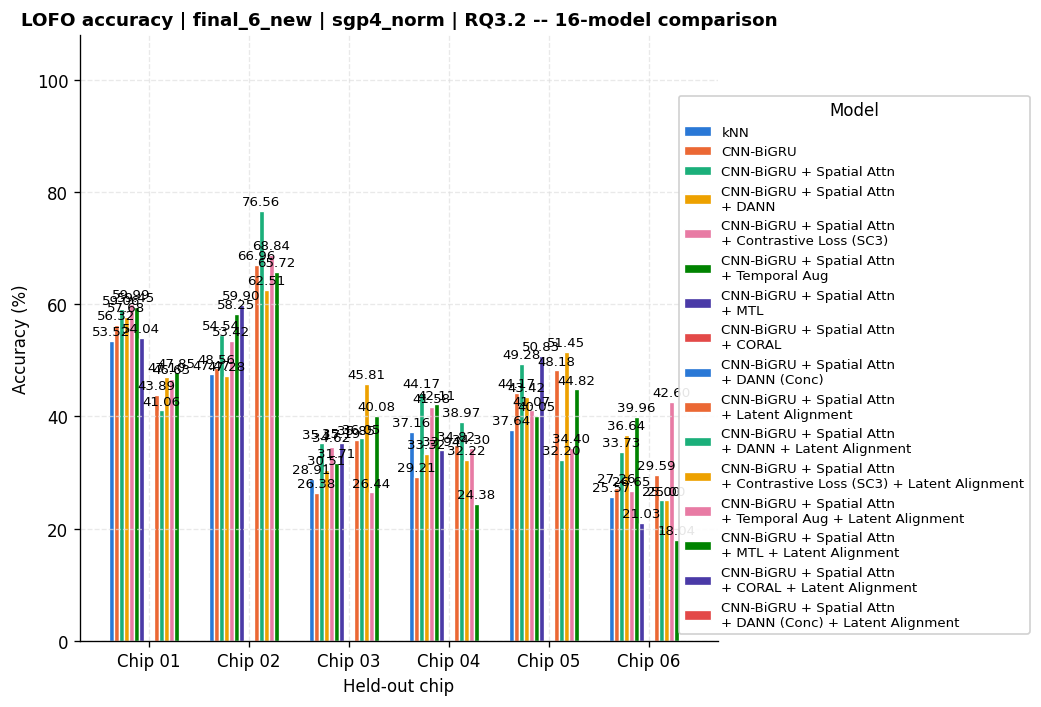

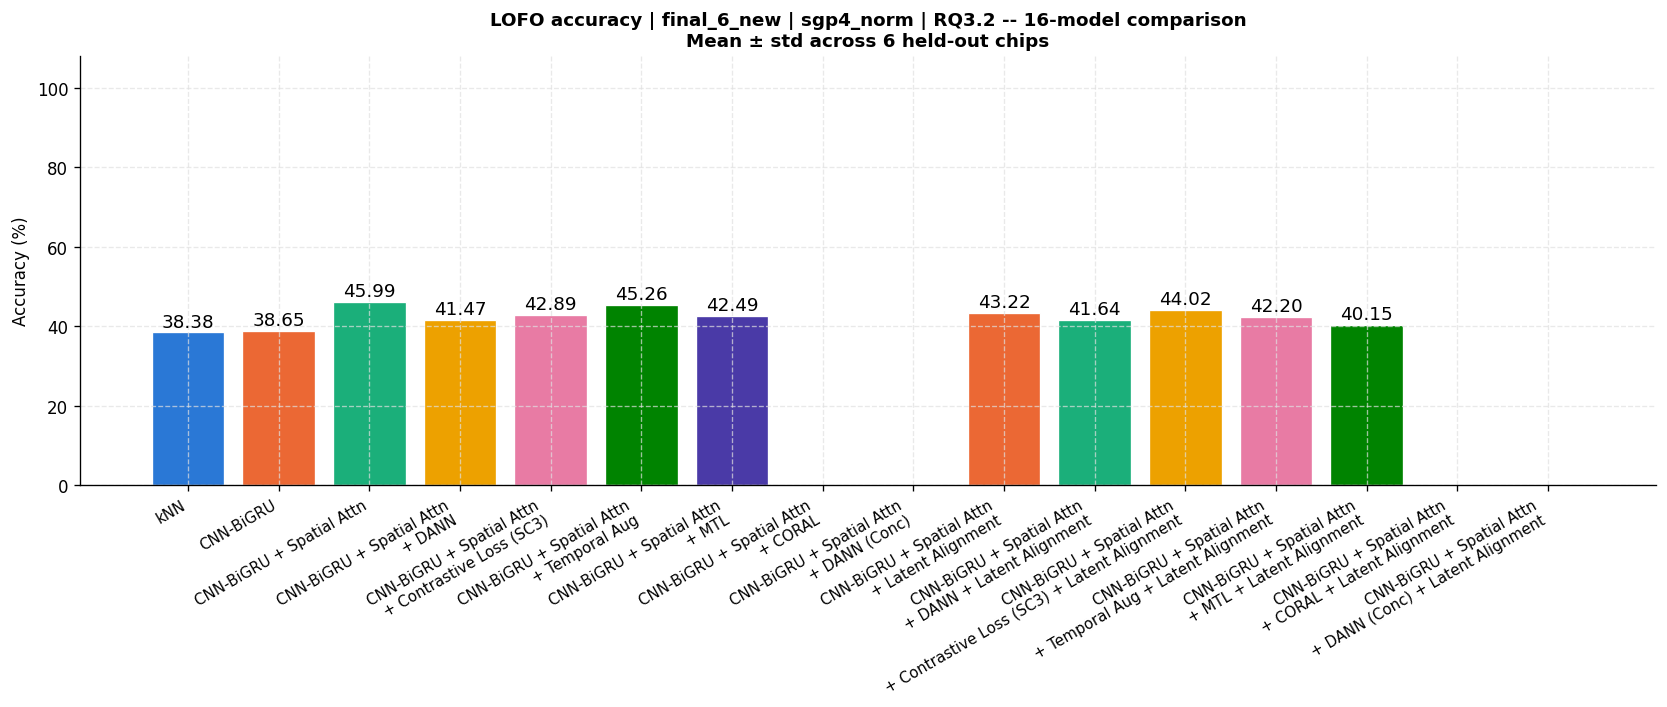

In [17]:
%matplotlib inline

# selected_held_outs = ['DDM_01']
selected_held_outs = []
if selected_held_outs:
    lofo_df_filtered = lofo_df[lofo_df['fold'].isin(selected_held_outs)].copy()
else:
    lofo_df_filtered = lofo_df.copy()

lofo_df_filtered = lofo_df_filtered[lofo_df_filtered['curve_type'] == 'sgp4_norm']
lofo_df_filtered = lofo_df_filtered[lofo_df_filtered['group'].isin(LOFO_GROUP_NAMES)]
# lofo_df_filtered = lofo_df_filtered[lofo_df_filtered['model'].isin(['cnn_gru_dual', 'cnn_gru_dual_attn_recon', 'cnn_gru_dual_attn_recon_pc_recenter'])]

for (group_name, curve_type), sub in lofo_df_filtered.groupby(['group', 'curve_type']):
    fold_labels = sorted(sub.fold.unique())
    for comparison, label in [(RQ3_2_COMPARISON, "RQ3.2 -- 16-model comparison")]:
        comp_sub = sub[sub.model.isin(comparison)]
        if comp_sub.empty:
            continue
        stats = plot_grouped_bar_by_model(
            comp_sub, x_col='fold', x_order=fold_labels, models=comparison, model_labels=FAMILY_LABELS,
            xlabel='Held-out chip', title=f'LOFO accuracy | {group_name} | {curve_type} | {label}',
            plot_fold=True, plot_summary=True, show_std=False,
        )
        # print(f"\nMean ± std across held-out chips ({group_name} | {curve_type} | {label}):")
        # print(stats.round(2))
    print("="*70)


### LaTeX table -- LOFO Base vs. + Latent Alignment, per held-out chip

In [18]:
def lofo_recenter_table(lofo_df, models, model_labels, dataset_order, pc_recenter):
    rows = []
    for m in models:
        key = f"{m}_pc_recenter" if pc_recenter else m
        sub = lofo_df[(lofo_df.model == key) & (lofo_df.curve_type == "sgp4_norm")
                      & (lofo_df.group == "final_6_new")]
        per_chip = [sub.loc[sub.fold == ds, "accuracy"].iloc[0]
                   if (sub.fold == ds).any() else np.nan for ds in dataset_order]
        row = {"Model": model_labels.get(m, m).replace(chr(10), " ")}
        row.update(dict(zip(dataset_order, per_chip)))
        vals = np.array(per_chip, dtype=float)
        row["Macro Avg (%)"] = np.nanmean(vals) if not np.all(np.isnan(vals)) else np.nan
        row["Macro Std (%)"] = np.nanstd(vals) if not np.all(np.isnan(vals)) else np.nan
        rows.append(row)
    return pd.DataFrame(rows)


def build_lofo_recenter_latex_table(df, dataset_order, caption, label):
    lines = [
        "\\begin{table}[htbp]",
        "    \\centering",
        f"    \\caption{{{caption}}}",
        f"    \\label{{{label}}}",
        "    \\small",
        "",
        "    \\resizebox{\\textwidth}{!}{",
        "    \\begin{tabular}{l" + "r" * len(dataset_order) + "r}",
        "    \\toprule",
        "    \\textbf{Model} & " + " & ".join(f"\\textbf{{{ds}}}" for ds in dataset_order)
        + " & \\textbf{Macro Avg} \\\\",
        "    \\midrule",
    ]
    for _, r in df.iterrows():
        cells = [f"{r[ds]:.2f}\\%" if pd.notna(r[ds]) else "--" for ds in dataset_order]
        macro = (f"{r['Macro Avg (%)']:.2f}\\% $\\pm$ {r['Macro Std (%)']:.2f}\\%"
                if pd.notna(r["Macro Avg (%)"]) else "--")
        lines.append(f"    {r['Model']} & {' & '.join(cells)} & {macro} \\\\")
    lines += ["    \\bottomrule", "    \\end{tabular}", "    }", "\\end{table}"]
    return "\n".join(lines)


base_table = lofo_recenter_table(lofo_df, RQ3_2_BASE_MODELS, FAMILY_LABELS, DATASET_NAMES, pc_recenter=False)
la_table   = lofo_recenter_table(lofo_df, PC_RECENTER_BASES, FAMILY_LABELS, DATASET_NAMES, pc_recenter=True)

print("Base model -- LOFO accuracy per held-out chip:")
print(base_table.round(2).to_string(index=False))
print("\n+ Latent Alignment -- LOFO accuracy per held-out chip:")
print(la_table.round(2).to_string(index=False))

base_latex = build_lofo_recenter_latex_table(
    base_table, DATASET_NAMES,
    caption="LOFO accuracy per held-out chip, base models (no latent alignment).",
    label="tab:lofo_base_per_chip",
)
la_latex = build_lofo_recenter_latex_table(
    la_table, DATASET_NAMES,
    caption="LOFO accuracy per held-out chip, with latent alignment (PC-recentered inference).",
    label="tab:lofo_latent_alignment_per_chip",
)
print("\n" + base_latex)
print("\n" + la_latex)


Base model -- LOFO accuracy per held-out chip:
                                            Model  Chip 01  Chip 02  Chip 03  Chip 04  Chip 05  Chip 06  Macro Avg (%)  Macro Std (%)
                                              kNN    53.52    47.47    28.91    37.16    37.64    25.57          38.38           9.72
                                        CNN-BiGRU    56.32    48.56    26.38    29.21    44.17    27.26          38.65          11.62
                         CNN-BiGRU + Spatial Attn    59.06    54.54    35.17    44.17    49.28    33.73          45.99           9.36
                  CNN-BiGRU + Spatial Attn + DANN    57.68    47.28    30.51    33.32    43.42    36.64          41.47           9.22
CNN-BiGRU + Spatial Attn + Contrastive Loss (SC3)    59.99    53.42    34.62    41.58    41.07    26.65          42.89          11.11
          CNN-BiGRU + Spatial Attn + Temporal Aug    59.45    58.25    31.71    42.11    40.05    39.96          45.26          10.16
               

### LaTeX table -- LOFO overall performance (main)

In [ ]:
def build_lofo_main_latex_table(lofo_df, group_name, curve_type, models, model_labels, caption, label):
    sub = lofo_df[(lofo_df.group == group_name) & (lofo_df.curve_type == curve_type)
                  & lofo_df.model.isin(models)]
    metrics = ['accuracy', 'f1', 'sensitivity', 'specificity']
    stats = sub.groupby('model')[metrics].agg(['mean', 'std']).reindex(models)
    best = {m: stats[(m, 'mean')].idxmax() for m in metrics}

    lines = [
        '\\begin{table}[htbp]',
        '    \\centering',
        f'    \\caption{{{caption}}}',
        f'    \\label{{{label}}}',
        '    \\small',
        '',
        '    \\resizebox{\\textwidth}{!}{',
        '    \\begin{tabular}{lrrrr}',
        '    \\toprule',
        '     & \\multicolumn{2}{c}{\\textbf{Overall}} & \\multicolumn{2}{c}{\\textbf{Macro Averages}} \\\\',
        '    \\cmidrule(lr){2-3} \\cmidrule(lr){4-5}',
        '    \\textbf{Model} & \\textbf{Accuracy} & \\textbf{F1} & \\textbf{Sensitivity} & \\textbf{Specificity} \\\\',
        '    \\midrule',
    ]
    for model in models:
        if model not in stats.index or stats.loc[model].isna().all():
            continue
        cells = []
        for m in metrics:
            v = f"{stats.loc[model, (m, 'mean')]:.2f}\\% $\\pm$ {stats.loc[model, (m, 'std')]:.2f}\\%"
            if best[m] == model:
                v = f'\\textbf{{{v}}}'
            cells.append(v)
        row_label = model_labels.get(model, model).replace(chr(10), ' ')
        lines.append(f'    {row_label} & {" & ".join(cells)} \\\\')
    lines += ['    \\bottomrule', '    \\end{tabular}', '    }', '\\end{table}']
    return '\n'.join(lines)


lofo_main_latex = build_lofo_main_latex_table(
    lofo_df, group_name='final_6_new', curve_type='sgp4_norm', models=RQ3_2_COMPARISON, model_labels=FAMILY_LABELS,
    caption=('LOFO cross-chip performance on final\\_6\\_new (SG p=4, normalized), reported as '
             'mean $\\pm$ standard deviation across the 6 held-out chips. Bold marks the best '
             'result per metric.'),
    label='tab:lofo_final6_new_sgp4norm',
)
print(lofo_main_latex)


### LaTeX table -- LOFO per-class Sensitivity/Specificity (appendix, landscape)\n\nCovers `RQ3_2_BASE_MODELS` only -- the `_pc_recenter` variants don't have a cached\n`y_preds_AC_*` array to build a per-class confusion matrix from (same scoping as the\nconfusion-matrix plots above).

In [ ]:
def get_lofo_class_names(group_name, curve_type, train_center_frac=LOFO_FRAC):
    lofo_results = load_lofo_results(group_name, curve_type, train_center_frac=train_center_frac)
    for fold_label, fold_entry in lofo_results.items():
        if not fold_label.startswith("lofo_"):
            continue
        cn = fold_entry.get('class_names')
        if cn:
            return list(cn)
    return []


def compute_lofo_per_class_sens_spec(group_name, curve_type, model, class_names, train_center_frac=LOFO_FRAC):
    """Mean +- std sens/spec per class, across the 6 held-out chips (LOFO folds)."""
    lofo_results = load_lofo_results(group_name, curve_type, train_center_frac=train_center_frac)
    preds_key = config.MODEL_KEY_MAP.get(model, (None,))[0]
    if preds_key is None:
        return None
    n_cls = len(class_names)
    fold_sens, fold_spec = [], []
    for fold_label, fold_entry in lofo_results.items():
        if not fold_label.startswith("lofo_"):
            continue
        res_entry = fold_entry.get(LOFO_FILTER)
        if res_entry is None or preds_key not in res_entry:
            continue
        y_true = np.concatenate(res_entry["y_trues_"])
        y_pred = np.concatenate(res_entry[preds_key])
        cm = confusion_matrix(y_true, y_pred, labels=range(n_cls))
        sens_c, spec_c = [], []
        for i in range(n_cls):
            tp = cm[i, i]
            fn = cm[i, :].sum() - tp
            fp = cm[:, i].sum() - tp
            tn = cm.sum() - tp - fn - fp
            sens_c.append(tp / (tp + fn) if (tp + fn) > 0 else np.nan)
            spec_c.append(tn / (tn + fp) if (tn + fp) > 0 else np.nan)
        fold_sens.append(sens_c)
        fold_spec.append(spec_c)
    if not fold_sens:
        return None
    fold_sens = np.array(fold_sens, dtype=float)
    fold_spec = np.array(fold_spec, dtype=float)
    return {
        'sens_mean': np.nanmean(fold_sens, axis=0) * 100, 'sens_std': np.nanstd(fold_sens, axis=0) * 100,
        'spec_mean': np.nanmean(fold_spec, axis=0) * 100, 'spec_std': np.nanstd(fold_spec, axis=0) * 100,
    }


def build_lofo_per_class_latex_table(group_name, curve_type, models, model_labels, class_names, caption, label):
    per_model = {}
    for m in models:
        stats = compute_lofo_per_class_sens_spec(group_name, curve_type, m, class_names)
        if stats is not None:
            per_model[m] = stats
    models_here = [m for m in models if m in per_model]

    model_header = ' & '.join(
        f'\\multicolumn{{2}}{{c}}{{\\textbf{{{model_labels.get(m, m).replace(chr(10), " ")}}}}}'
        for m in models_here)
    model_cmid = ' '.join(f'\\cmidrule(lr){{{2 + 2*i}-{3 + 2*i}}}' for i in range(len(models_here)))
    metric_row = ' & '.join('\\textbf{Sens.} & \\textbf{Spec.}' for _ in models_here)

    lines = [
        '\\begin{landscape}',
        '\\begin{table}[!htbp]',
        '    \\centering',
        f'    \\caption{{{caption}}}',
        f'    \\label{{{label}}}',
        '    \\small',
        '    \\resizebox{\\textwidth}{!}{',
        '    \\begin{tabular}{l' + 'cc' * len(models_here) + '}',
        '    \\toprule',
        f'     & {model_header} \\\\',
        f'    {model_cmid}',
        f'    \\textbf{{Class}} & {metric_row} \\\\',
        '    \\midrule',
    ]
    for ci, cname in enumerate(class_names):
        sens_vals = {m: per_model[m]['sens_mean'][ci] for m in models_here}
        spec_vals = {m: per_model[m]['spec_mean'][ci] for m in models_here}
        best_sens = max(sens_vals, key=sens_vals.get) if sens_vals else None
        best_spec = max(spec_vals, key=spec_vals.get) if spec_vals else None
        cells = []
        for m in models_here:
            s = per_model[m]
            sens_str = f"{s['sens_mean'][ci]:.2f}\\% $\\pm$ {s['sens_std'][ci]:.2f}\\%"
            spec_str = f"{s['spec_mean'][ci]:.2f}\\% $\\pm$ {s['spec_std'][ci]:.2f}\\%"
            if m == best_sens:
                sens_str = f'\\textbf{{{sens_str}}}'
            if m == best_spec:
                spec_str = f'\\textbf{{{spec_str}}}'
            cells.append(sens_str)
            cells.append(spec_str)
        lines.append(f"    {cname} & " + " & ".join(cells) + " \\\\")
    lines += ['    \\bottomrule', '    \\end{tabular}', '    }', '\\end{table}', '\\end{landscape}']
    return '\n'.join(lines)


lofo_class_names = get_lofo_class_names('final_6_new', 'ori_curve_sg_p4_norm')
lofo_per_class_latex = build_lofo_per_class_latex_table(
    'final_6_new', 'ori_curve_sg_p4_norm', RQ3_2_BASE_MODELS, FAMILY_LABELS, lofo_class_names,
    caption=('Per-class sensitivity and specificity for LOFO cross-chip evaluation on '
             'final\\_6\\_new (SG p=4, normalized). Results are mean $\\pm$ standard deviation '
             'across the 6 held-out chips. Bold marks the best result per class.'),
    label='tab:lofo_per_class_sens_spec',
)
print(lofo_per_class_latex)
